In [308]:
import kagglehub

path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")

In [309]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [310]:
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")

In [311]:
data_train.device_category.value_counts()

device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64

In [312]:
data_test.device_category.value_counts()

device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

In [313]:
# Since we have 1 more category in the test set, we will merge the two datasets
data = pd.concat([data_train, data_test], axis=0, ignore_index=True)
data.shape

(1900, 298)

In [314]:
# Shuffle the dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,motion_sensor
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,TV
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,security_camera


Text(0.5, 1.0, 'Total Missing Values')

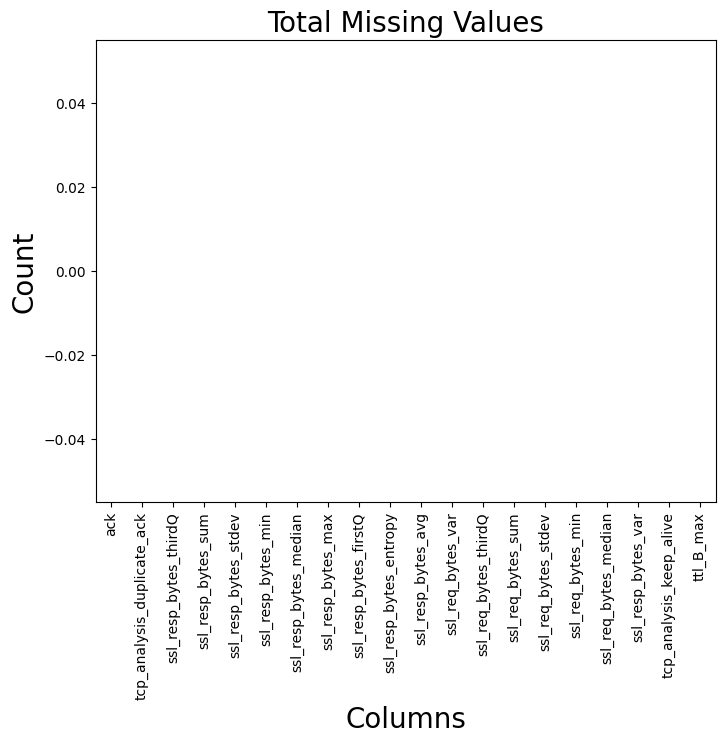

In [315]:
total = data.isnull().sum().sort_values(ascending=False)
total_select = total.head(20)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)
plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)


In [316]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['device_category'] = le.fit_transform(data['device_category'])
data['device_category'].value_counts()

device_category
3    200
0    200
8    200
4    200
2    200
5    200
1    200
6    200
7    200
9    100
Name: count, dtype: int64

In [317]:
data.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,3
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,0
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,8
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,8
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,4


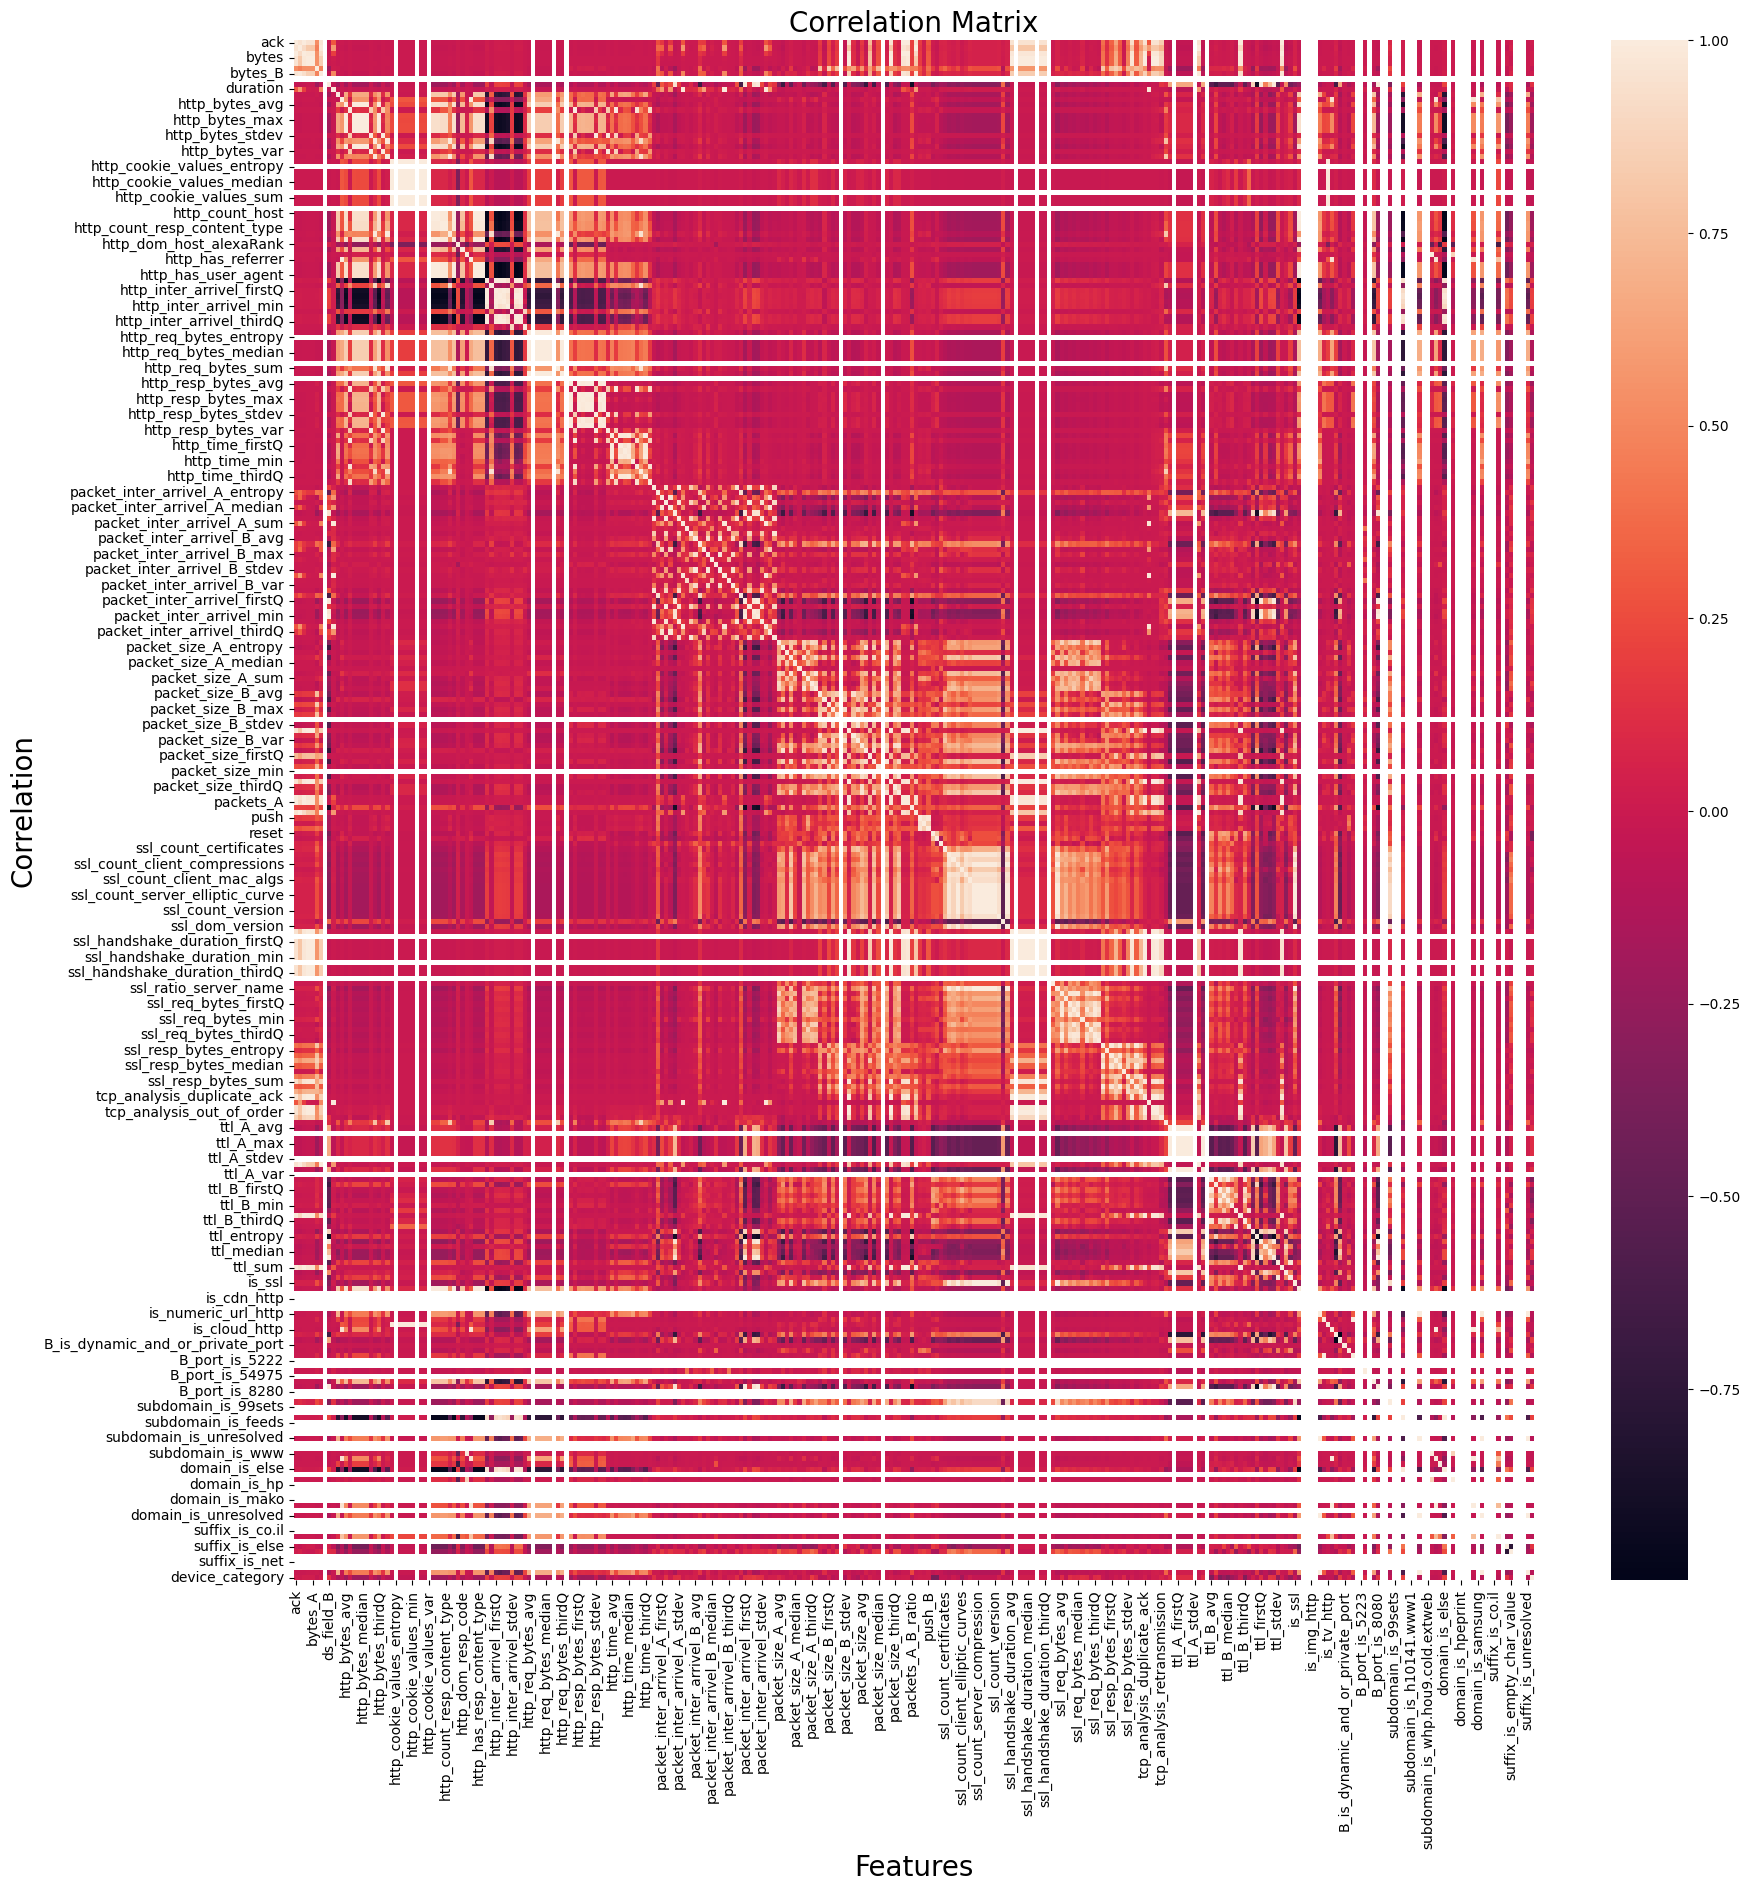

In [318]:
# Correlation Matrix
plt.figure(figsize=(20, 20))
sns.heatmap(data=data.corr())
plt.title("Correlation Matrix", fontsize = 20)
plt.xlabel("Features", fontsize = 20)
plt.ylabel("Correlation", fontsize = 20)
plt.show()

In [319]:
corr = data.corr().abs()['device_category'].sort_values(ascending=False)
drop_cols = corr[corr < 0.1].index
drop_cols

Index(['ssl_req_bytes_median', 'ttl_B_var', 'http_time_max',
       'packet_size_B_avg', 'http_time_thirdQ', 'http_time_avg',
       'http_time_median', 'packet_size_B_max', 'http_time_firstQ',
       'packet_inter_arrivel_B_firstQ',
       ...
       'packets_B', 'ack_A', 'packet_size_avg', 'packet_size_thirdQ',
       'packet_inter_arrivel_A_firstQ', 'ssl_count_client_ciphersuites',
       'packet_inter_arrivel_A_entropy', 'packet_size_A_sum', 'ttl_B_entropy',
       'packet_size_A_max'],
      dtype='object', length=160)

In [320]:
data = data.drop(drop_cols, axis=1)
data.shape

(1900, 138)

In [321]:
X = data.drop(columns=["device_category"])
y = data["device_category"]

In [322]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [323]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [324]:
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/Users/humbertoangelplataduran/Documents/6 Semester/BusinessDataScience/Proyect_2/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:08:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.91      0.97      0.94        31
           1       1.00      1.00      1.00        36
           2       0.70      0.68      0.69        34
           3       1.00      0.98      0.99        41
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        40
           6       0.66      0.69      0.68        36
           7       0.92      0.98      0.95        49
           8       0.98      0.88      0.92        48
           9       0.64      0.64      0.64        22

    accuracy                           0.90       380
   macro avg       0.88      0.88      0.88       380
weighted avg       0.90      0.90      0.90       380



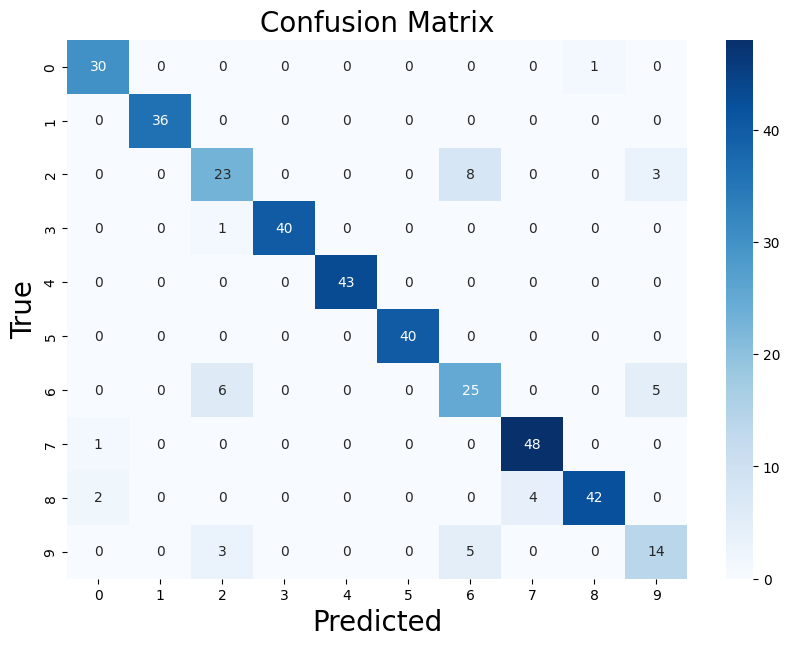

In [325]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()